# MoE Paper Figures

Produces exactly three figures for the paper:
1. Expert load balance (sanity check)
2. Kapanji group × Expert gate weight heatmap
3. Morphology heatmap (PWD users only, skips users with `gesture_features=None`)

**NOTE:** I switched the analysis in this NB to 1) only use 25 episodes instead of 200 (since we are doing viz not results benchmarking), and 2) got rid of the adaptation (not totally sure about this, it will obviously speed things up but we'll see if it actually has useful output or not)

## 0. Imports

In [ ]:
import sys
import os
import json
import pickle
import warnings
from pathlib import Path

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 500
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = r"C:\Users\kdmen\Repos\pers-gest-cls\system"
sys.path.insert(0, PROJECT_ROOT)

from MOE.MOE_encoder import build_MOE_model
from MOE.MOE_analysis import RoutingCollector, RoutingAnalyzer, RoutingRecord
from MAML.mamlpp import mamlpp_adapt, _normalize_step_item, named_param_dict, FunctionalModel
from MAML.maml_data_pipeline import get_maml_dataloaders

print('Imports OK')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Imports OK
PyTorch: 2.7.1+cu128
CUDA available: True


## 1. Load train/val PID split

In [2]:
SPLIT_JSON_PATH = r"C:\Users\kdmen\Repos\pers-gest-cls\system\fixed_user_splits\hpo_strat_kapanji_split.json"
FOLD_KEY = 0

KAPANJI_GROUPS = {
    'Non-disabled Kapanji':  {'P011', 'P010', 'P008', 'P006', 'P005', 'P004'},
    'Disabled Kapanji':      {'P111', 'P119', 'P124', 'P110', 'P112', 'P123',
                              'P132', 'P126', 'P131', 'P104', 'P116'},
    'Disabled Non-Kapanji':  {'P102', 'P114', 'P107', 'P103', 'P125', 'P127',
                              'P128', 'P118', 'P108', 'P122', 'P106', 'P115',
                              'P105', 'P109', 'P121'},
}

with open(SPLIT_JSON_PATH, 'r') as f:
    split_data = json.load(f)

fold        = split_data[FOLD_KEY]
TRAIN_PIDS  = fold['train']
HP_VAL_PIDS = set(fold['val'])
TEST_PIDS   = set(fold['test'])
VAL_PIDS    = HP_VAL_PIDS | TEST_PIDS
ALL_PIDS = set(TRAIN_PIDS) | VAL_PIDS

assert len(set(TRAIN_PIDS) & VAL_PIDS) == 0, 'PID leakage between train and val+test!'

print(f'Train PIDs ({len(TRAIN_PIDS)}): {sorted(TRAIN_PIDS)}')
print(f'Val+Test (used for routing analysis) ({len(VAL_PIDS)}): {sorted(VAL_PIDS)}')

Train PIDs (24): ['P006', 'P008', 'P010', 'P011', 'P102', 'P103', 'P106', 'P107', 'P108', 'P110', 'P111', 'P112', 'P114', 'P115', 'P118', 'P119', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P132']
Val+Test (used for routing analysis) (8): ['P004', 'P005', 'P104', 'P105', 'P109', 'P116', 'P121', 'P131']


## 2. Config

In [3]:
config = {
    # NOTE: OVERWROTE so that we run all PIDs, not just the withheld users!
    'train_PIDs':                               [],
    'val_PIDs':                                 ALL_PIDS,

    'model_type':                               'DeepCNNLSTM',
    'use_MOE':                                  True,
    'MOE_placement':                            'encoder',
    'num_experts':                              22,          # C1 wins (C2 had 24 — also matches your figure note!)
    'MOE_ctx_hidden_dim':                       32,
    'MOE_ctx_out_dim':                          64,
    'MOE_gate_temperature':                     1.5290172211651742,   # C1 wins
    'MOE_top_k':                                9,           # C1 wins
    'top_k':                                    9,           # C1 wins (kept for compat)
    'MOE_dropout':                              0.03653577545411608,  # C1 wins
    'MOE_expert_expand':                        1.0,
    'MOE_mlp_hidden_mult':                      1.0,
    'MOE_aux_coeff':                            0.03282324399711515,  # C1 wins
    'MOE_use_shared_expert':                    False,       # C1 only
    'MOE_importance_coeff':                     0.0,         # C1 only
    'MOE_routing_signal':                       'context_proj',       # C1 only
    'apply_MOE_aux_loss_inner_outer':           'outer',
    'FILM_on_context_or_demo':                  'context',
    'gate_type':                                'context_feature_demo',
    'expert_architecture':                      'MLP',
    'front_end_stride':                         0,
    'MOE_log_every':                            5,
    'MOE_plot_dir':                             None,

    'emg_in_ch':                                16,
    'imu_in_ch':                                72,
    'use_imu':                                  True,
    'multimodal':                               True,
    'use_demographics':                         False,
    'use_film_x_demo':                          False,
    'demo_in_dim':                              12,
    'sequence_length':                          64,
    'augment':                                  False,
    'feature_engr':                             None,
    'padding':                                  0,
    'cnn_base_filters':                         64,
    'cnn_filters':                              64,          # C2 only
    'cnn_layers':                               3,
    'cnn_kernel':                               5,
    'groupnorm_num_groups':                     8,
    'lstm_hidden':                              64,
    'lstm_layers':                              3,
    'dropout':                                  0.1,
    'bidirectional':                            True,
    'head_type':                                'mlp',
    'use_GlobalAvgPooling':                     True,
    'use_batch_norm':                           False,

    'meta_learning':                            True,
    'n_way':                                    3,
    'k_shot':                                   1,
    'q_query':                                  9,
    'num_classes':                              10,
    'pretrain_num_classes':                     10,
    'available_gesture_classes':                [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    'maml_gesture_classes':                     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    'maml_inner_steps':                         10,
    'maml_inner_steps_eval':                    10,
    'maml_alpha_init':                          0.0009734890497675034,  # C1 wins
    'maml_alpha_init_eval':                     0.00506597432775958,    # C1 wins
    'maml_use_lslr':                            True,
    'use_lslr_at_eval':                         False,
    'maml_opt_order':                           'first',
    'maml_first_order_to_second_order_epoch':   1000000,
    'use_maml_msl':                             'hybrid',
    'maml_msl_num_epochs':                      31,          # C1 wins
    'meta_batchsize':                           24,
    'label_smooth':                             0.05,
    'ft_label_smooth':                          0.0,
    'ft_support_reps':                          [1],         # C1 only
    'ft_query_reps':                            [2, 3, 4, 5, 6, 7, 8, 9, 10],  # C1 only
    'enable_inner_loop_optimizable_bn_params':  False,
    'track_gradient_alignment':                 False,

    'optimizer':                                'adam',
    'learning_rate':                            0.00019506115991520216, # C1 wins
    'weight_decay':                             0.0008873572502558012,  # C1 wins
    'gradient_clip_max_norm':                   10.0,
    'lr_scheduler_factor':                      0.1,
    'lr_scheduler_patience':                    6,
    'use_cosine_outer_lr':                      False,
    'use_earlystopping':                        False,       # C1 wins
    'earlystopping_min_delta':                  0.005,
    'earlystopping_patience':                   8,

    'pretrain_approach':                        None,
    'pretrained_model_filename':                None,
    'pretrain_dir':                             'C:\\Users\\kdmen\\Repos\\pers-gest-cls\\hpo_best_models\\',

    'target_trial_reps':                        None,
    'train_reps':                               [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'val_reps':                                 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'episodes_per_epoch_train':                 500,         # C1 wins
    'num_eval_episodes':                        200,
    'num_workers':                              0,
    'use_label_shuf_meta_aug':                  True,        # C1 wins
    'utilization_ratio':                        0.4090909090909091,  # C1 only

    'seed':                                     42,          # C2 only
    'debug_one_episode':                        False,
    'debug_five_episodes':                      False,
    'debug_one_user_only':                      False,
    'debug_verbose':                            False,
    'subject_specific_model':                   False,       # C2 only
    'NOTS':                                     True,
    'ablation_id':                              'M0',
    'dfs_load_path':                            'C:\\Users\\kdmen\\Repos\\pers-gest-cls\\dataset\\meta-learning-sup-que-ds\\',
    'user_split_json_filepath':                 SPLIT_JSON_PATH,
    'models_save_dir':                          None,
    'results_save_dir':                         r'C:\Users\kdmen\Repos\pers-gest-cls\paper_figures',
    'device':                                   'cuda' if torch.cuda.is_available() else 'cpu',
    'demo_dim_labels': [                        # C2 only
        'time_disabled', 'age', 'BMI', 'DASH_score',
        'disability_coding_MD', 'disability_coding_No_Disability',
        'disability_coding_PN', 'disability_coding_SCI', 'disability_coding_other',
        'handedness_Right',
        'gender_Non-binary', 'gender_Woman',
    ],
}

print(f"Device          : {config['device']}")
print(f"Val PIDs ({len(config['val_PIDs'])}): {sorted(config['val_PIDs'])}")

Device          : cuda
Val PIDs (32): ['P004', 'P005', 'P006', 'P008', 'P010', 'P011', 'P102', 'P103', 'P104', 'P105', 'P106', 'P107', 'P108', 'P109', 'P110', 'P111', 'P112', 'P114', 'P115', 'P116', 'P118', 'P119', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P131', 'P132']


## 3. Load data (val+test users)

In [4]:
TENSOR_DICT_PATH = r"C:\Users\kdmen\Repos\pers-gest-cls\dataset\meta-learning-sup-que-ds\segfilt_withMorphology_tensor_dict.pkl"

_, val_dl = get_maml_dataloaders(config, TENSOR_DICT_PATH)
print(f'Val dataloader: {len(val_dl)} episodes')

[get_maml_dataloaders] Train PIDs (0): []
[get_maml_dataloaders] Val   PIDs (32):   ['P004', 'P005', 'P006', 'P008', 'P010', 'P011', 'P102', 'P103', 'P104', 'P105', 'P106', 'P107', 'P108', 'P109', 'P110', 'P111', 'P112', 'P114', 'P115', 'P116', 'P118', 'P119', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P131', 'P132']
[get_maml_dataloaders] num_eval_episodes per val user: 200
[get_maml_dataloaders] Total val episodes in cache: 6400
[get_maml_dataloaders] use_label_shuf_meta_aug: True
Val dataloader: 6400 episodes


## 4. Load model checkpoint

In [5]:
def load_maml_checkpoint(checkpoint_path: Path) -> tuple:
    print(f"Loading MAML checkpoint: {checkpoint_path}")
    assert checkpoint_path.exists(), f"Checkpoint not found: {checkpoint_path}"

    ckpt   = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    config = ckpt["config"]

    device           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    config["device"] = device

    if config["use_MOE"]:
        from MOE.MOE_encoder import build_MOE_model
        model = build_MOE_model(config)
    else:
        from pretraining.pretrain_models import build_model
        model = build_model(config)

    if config.get("maml_use_lslr", False):
        from MAML.mamlpp import PerParamPerStepLSLR, named_param_dict
        temp_params = named_param_dict(model, require_grad_only=True)
        model._lslr = PerParamPerStepLSLR(
            named_params = temp_params.items(),
            inner_steps  = config["maml_inner_steps"],
            init_lr      = config["maml_alpha_init"],
            learnable    = True,
            device       = device,
        ).to(device)

    raw_sd     = ckpt["model_state_dict"]
    remapped_sd = {}
    n_remapped  = 0
    for k, v in raw_sd.items():
        new_k = k.replace("ctx_proj.", "router.projector.").replace("ctx_proj-", "router-projector-")
        if new_k != k:
            n_remapped += 1
        remapped_sd[new_k] = v
    if n_remapped > 0:
        print(f"  [ckpt remap] Remapped {n_remapped} keys: ctx_proj -> router.projector")

    model.load_state_dict(remapped_sd)
    model.to(device)
    model.eval()
    print(f"  Best val acc    : {ckpt.get('best_val_acc', 'N/A')}")
    return model, config

In [6]:
del config

CHECKPOINT_PATH = r"C:\Users\kdmen\Repos\pers-gest-cls\models\final_eval_models\best_M0_model.pt"

model, loaded_config = load_maml_checkpoint(Path(CHECKPOINT_PATH))
config = loaded_config

# Restore fields not saved in checkpoint
config['demo_dim_labels'] = [
    'time_disabled', 'age', 'BMI', 'DASH_score',
    'disability_coding_MD', 'disability_coding_No_Disability',
    'disability_coding_PN', 'disability_coding_SCI', 'disability_coding_other',
    'handedness_Right', 'gender_Non-binary', 'gender_Woman',
]
config['num_eval_episodes'] = 200
config['val_PIDs']  = VAL_PIDS
config['train_PIDs'] = TRAIN_PIDS
config['user_split_json_filepath'] = SPLIT_JSON_PATH
config['results_save_dir'] = r'C:\Users\kdmen\Repos\pers-gest-cls\paper_figures'

E    = config['num_experts']
TOPK = config['MOE_top_k']
n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {config['model_type']} (MoE encoder) | {n_params:,} parameters")
print(f"E={E}, top_k={TOPK}, ideal selection freq per expert = {TOPK/E:.3f}")

Loading MAML checkpoint: C:\Users\kdmen\Repos\pers-gest-cls\models\final_eval_models\best_M0_model.pt
  Best val acc    : 0.9066927083333334
Model loaded: DeepCNNLSTM (MoE encoder) | 5,538,216 parameters
E=22, top_k=9, ideal selection freq per expert = 0.409


## 5. Collect routing data (post-adaptation, query-only)

**This is the slow cell.** If you saved a RoutingRecord previously, skip to Cell 5b to reload it.

**To switch to ALL users (including train):** Before running this cell, rebuild `val_dl` over
all PIDs by setting `config['val_PIDs'] = set(TRAIN_PIDS) | VAL_PIDS` and re-running Cell 3.
There is no shortcut — routing vectors for train users have never been computed.

In [7]:
# ── Cell 5_FAST: Routing collection — no MAML adaptation, reduced episodes ──
# 
# Rationale for skipping adaptation:
#   The MoE gate is driven by the encoder's context signal (EMG/IMU input),
#   not the task head. MAML inner-loop updates the head + LSLR step sizes.
#   Pre-adaptation gate weights should be nearly identical to post-adaptation.
#   If results look suspicious, rerun full Cell 5 to confirm.
#
# Set this to 20-50; 200 is overkill for routing statistics
NUM_EPISODES_PER_USER = 25

collector_fast = RoutingCollector(
    num_experts = E,
    model_name  = config['model_type'],
)

device     = config['device']
multimodal = bool(config.get('multimodal', True))
n_episodes = 0
n_skipped  = 0

episodes_seen_per_user = {}   # pid -> count

model.eval()

for step_item in val_dl:
    episodes = _normalize_step_item(step_item)
    for episode in episodes:
        query_batch = episode['query']

        user_id = episode['user_id']
        if isinstance(user_id, (list, tuple)):
            episode_pids = [str(p) for p in user_id]
        else:
            episode_pids = str(user_id)

        # Determine the representative PID for throttling
        rep_pid = episode_pids[0] if isinstance(episode_pids, list) else episode_pids

        if episodes_seen_per_user.get(rep_pid, 0) >= NUM_EPISODES_PER_USER:
            continue
        episodes_seen_per_user[rep_pid] = episodes_seen_per_user.get(rep_pid, 0) + 1

        qemg    = query_batch['emg'].to(device)
        qlabels = query_batch['labels'].to(device)
        qimu    = query_batch.get('imu')
        if qimu is not None and multimodal:
            qimu = qimu.to(device)
        else:
            qimu = None

        if isinstance(episode_pids, str):
            episode_pids = [episode_pids] * qemg.size(0)

        # NO mamlpp_adapt — direct forward pass on M0 weights
        with torch.no_grad():
            out = model(qemg, qimu, return_routing=True)

        if not (isinstance(out, tuple) and len(out) == 2 and isinstance(out[1], dict)):
            n_skipped += 1
            continue

        _, routing_info = out
        gate_w = routing_info.get('gate_weights')
        if gate_w is None:
            n_skipped += 1
            continue

        demo        = query_batch.get('demo')
        gesture_ids = query_batch.get('global_labels', qlabels).cpu()

        collector_fast.add(
            gate_weights   = gate_w.cpu(),
            gesture_labels = gesture_ids,
            pids           = episode_pids,
            demographics   = demo.cpu() if demo is not None else None,
        )
        n_episodes += 1

print(f'Collected {n_episodes} episodes, skipped {n_skipped}')
print(f'Episodes per user: { {k: v for k, v in sorted(episodes_seen_per_user.items())} }')
record = collector_fast.finalize()
print(f'Total query samples : {record.gate_weights.shape[0]}')
print(f'Gate weights shape  : {record.gate_weights.shape}  (N x E)')
print(f'Unique users        : {len(set(record.pids))}')

Collected 800 episodes, skipped 0
Episodes per user: {'P004': 25, 'P005': 25, 'P006': 25, 'P008': 25, 'P010': 25, 'P011': 25, 'P102': 25, 'P103': 25, 'P104': 25, 'P105': 25, 'P106': 25, 'P107': 25, 'P108': 25, 'P109': 25, 'P110': 25, 'P111': 25, 'P112': 25, 'P114': 25, 'P115': 25, 'P116': 25, 'P118': 25, 'P119': 25, 'P121': 25, 'P122': 25, 'P123': 25, 'P124': 25, 'P125': 25, 'P126': 25, 'P127': 25, 'P128': 25, 'P131': 25, 'P132': 25}
Total query samples : 21600
Gate weights shape  : torch.Size([21600, 22])  (N x E)
Unique users        : 32


## 5b. Save / reload RoutingRecord (skip Cell 5 on future runs)

In [8]:
from MOE.MOE_analysis import save_routing_record, load_routing_record

RECORD_SAVE_PATH = r"C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\routing_record_M0.pt"

# Uncomment to save after first run:
# save_routing_record(record, RECORD_SAVE_PATH)
# print(f'Saved to {RECORD_SAVE_PATH}')

# Uncomment to reload and skip cells 3–5 on future runs:
# record = load_routing_record(RECORD_SAVE_PATH)
# E      = record.gate_weights.shape[1]
# print(f'Loaded {record.gate_weights.shape[0]} samples, {len(set(record.pids))} users')

## 5c. Build user-level aggregates

In [9]:
pids_arr   = np.array(record.pids)
gw_all     = record.gate_weights.float()

unique_pids = sorted(set(record.pids))
N_users     = len(unique_pids)

# User-level mean gate weight vectors — shape (N_users, E)
user_gw = np.stack([
    gw_all[pids_arr == uid].mean(0).numpy()
    for uid in unique_pids
])

print(f'N_users   : {N_users}')
print(f'user_gw shape: {user_gw.shape}  (N_users x E)')

N_users   : 32
user_gw shape: (32, 22)  (N_users x E)


---
# FIGURE 1 — Expert Load Balance

In [ ]:
  #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)

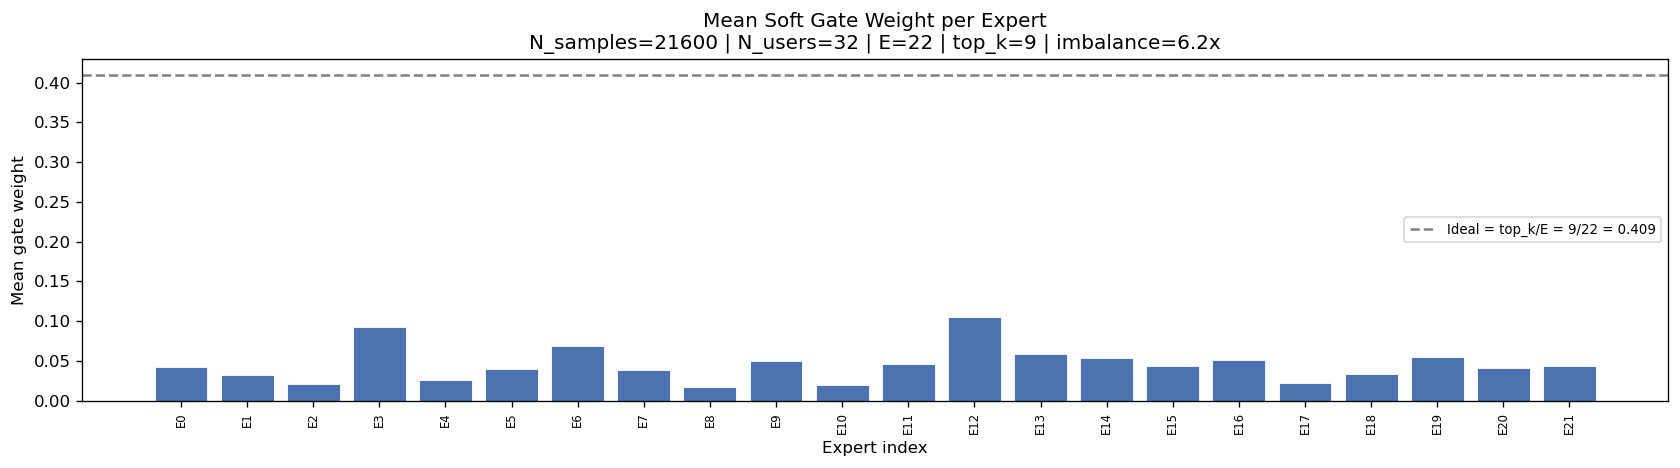

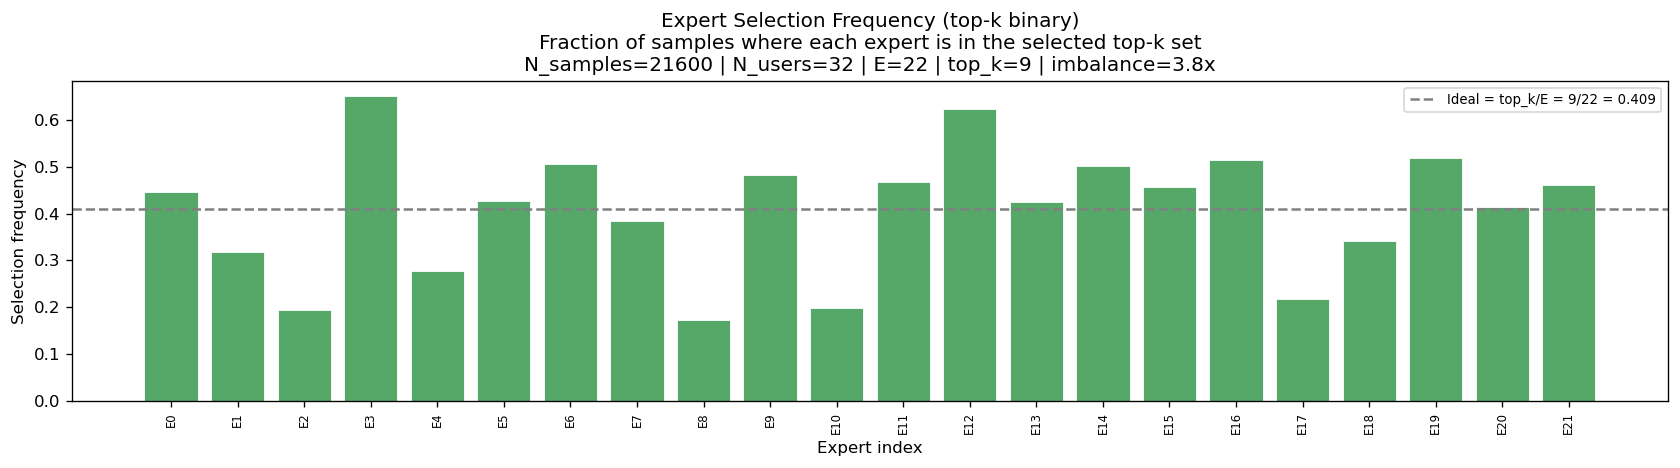

Selection freq — max: 0.651  min: 0.173  imbalance: 3.8x


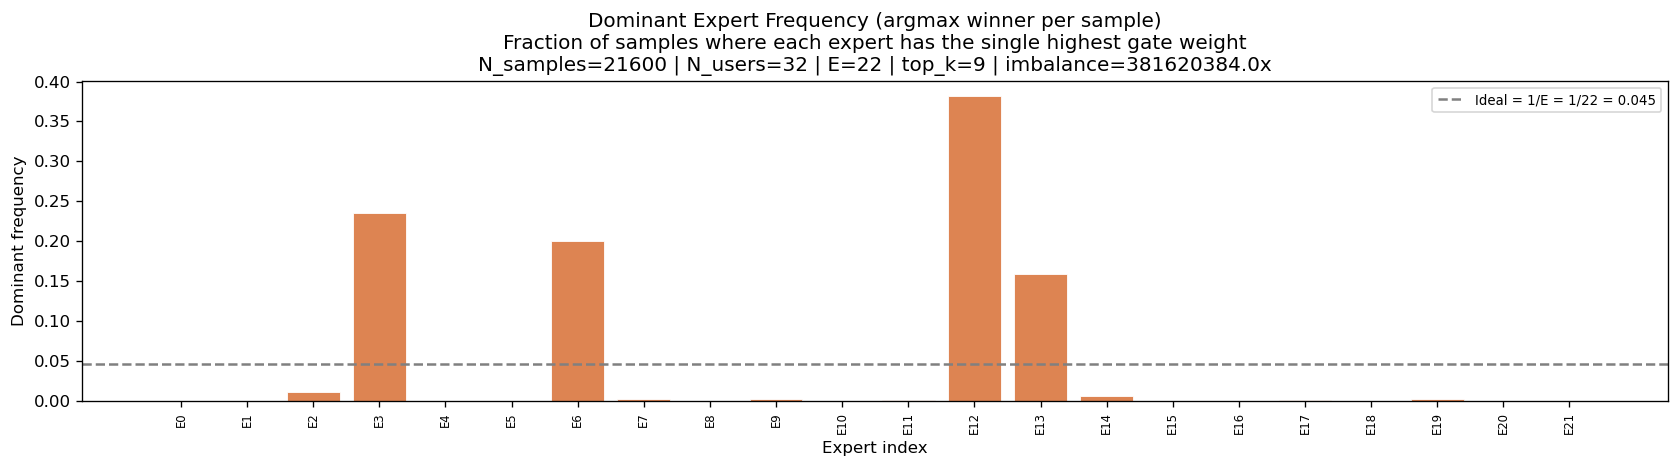

Dominant freq  — max: 0.382  min: 0.000  imbalance: 381620384.0x


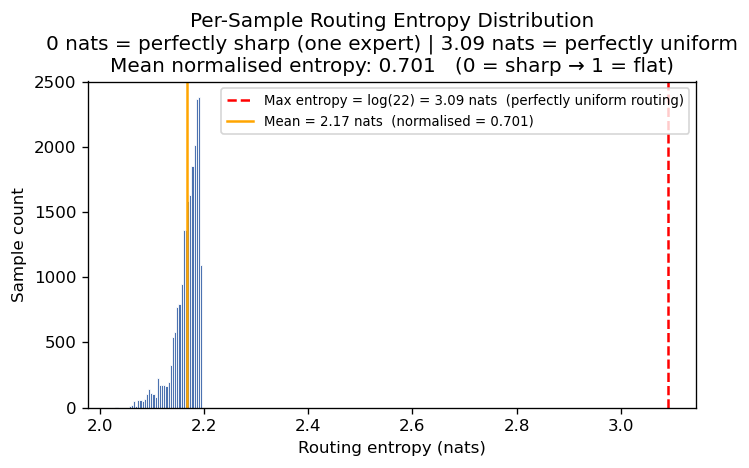


Entropy summary:
  Mean (normalised, 0=sharp→1=flat) : 0.7011
  Mean (nats)                        : 2.1671
  Std  (nats)                        : 0.0246
  Max possible (log E = log 22)     : 3.0910


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 (replaced) — Four separate load-balance / routing diagnostics
#
# Replace the old single "Expert Load Balance" bar chart cell with this cell.
# Requires:  record, E, TOPK, N_users  (all produced by Cell 5 / 5c)
# ─────────────────────────────────────────────────────────────────────────────

analyzer = RoutingAnalyzer(record)
lb       = analyzer.load_balance()   # now returns all four metrics + ideals
ent      = analyzer.routing_entropy()

E_labels = [f'E{i}' for i in range(E)]
x        = np.arange(E)
fig_w    = max(8, E * 0.55 + 2)

# ── Helper: shared axis formatting ───────────────────────────────────────────
def _fmt_expert_ax(ax, title, ylabel, ideal_val, ideal_label, imbalance_ratio):
    ax.axhline(ideal_val, color='gray', linestyle='--', label=ideal_label)
    ax.set_xlabel('Expert index')
    ax.set_ylabel(ylabel)
    ax.set_title(
        f'{title}\n'
        f'N_samples={record.gate_weights.shape[0]} | N_users={N_users} | '
        f'E={E} | top_k={lb["top_k"]} | imbalance={imbalance_ratio:.1f}x'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(E_labels, rotation=90, fontsize=7)
    ax.legend(fontsize=8)


# ── Figure 1a: Mean soft gate weight ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(fig_w, 4))
ax.bar(x, lb['expert_soft_fraction'], color='#4C72B0', edgecolor='white', linewidth=0.5)
_fmt_expert_ax(
    ax,
    title          = 'Mean Soft Gate Weight per Expert',
    ylabel         = 'Mean gate weight',
    ideal_val      = lb['ideal_selection_fraction'],
    ideal_label    = f"Ideal = top_k/E = {lb['top_k']}/{E} = {lb['ideal_selection_fraction']:.3f}",
    imbalance_ratio = lb['soft_imbalance_ratio'],
)
fig.tight_layout()
plt.show()

# ── Figure 1b: Expert selection frequency (top-k binary) ─────────────────────
fig, ax = plt.subplots(figsize=(fig_w, 4))
ax.bar(x, lb['expert_selection_freq'], color='#55A868', edgecolor='white', linewidth=0.5)
_fmt_expert_ax(
    ax,
    title          = 'Expert Selection Frequency (top-k binary)\n'
                     'Fraction of samples where each expert is in the selected top-k set',
    ylabel         = 'Selection frequency',
    ideal_val      = lb['ideal_selection_fraction'],
    ideal_label    = f"Ideal = top_k/E = {lb['top_k']}/{E} = {lb['ideal_selection_fraction']:.3f}",
    imbalance_ratio = lb['selection_imbalance_ratio'],
)
fig.tight_layout()
plt.show()

print(f"Selection freq — max: {max(lb['expert_selection_freq']):.3f}  "
      f"min: {min(lb['expert_selection_freq']):.3f}  "
      f"imbalance: {lb['selection_imbalance_ratio']:.1f}x")

# ── Figure 1c: Dominant expert frequency (argmax) ────────────────────────────
fig, ax = plt.subplots(figsize=(fig_w, 4))
ax.bar(x, lb['expert_dominant_freq'], color='#DD8452', edgecolor='white', linewidth=0.5)
_fmt_expert_ax(
    ax,
    title          = 'Dominant Expert Frequency (argmax winner per sample)\n'
                     'Fraction of samples where each expert has the single highest gate weight',
    ylabel         = 'Dominant frequency',
    ideal_val      = lb['ideal_dominant_fraction'],
    ideal_label    = f"Ideal = 1/E = 1/{E} = {lb['ideal_dominant_fraction']:.3f}",
    imbalance_ratio = lb['dominant_imbalance_ratio'],
)
fig.tight_layout()
plt.show()

print(f"Dominant freq  — max: {max(lb['expert_dominant_freq']):.3f}  "
      f"min: {min(lb['expert_dominant_freq']):.3f}  "
      f"imbalance: {lb['dominant_imbalance_ratio']:.1f}x")

# ── Figure 1d: Per-sample routing entropy histogram ──────────────────────────
h_vals  = np.array(lb['per_sample_entropy'])
max_h   = ent['max_entropy_nats']
mean_h  = ent['mean_entropy_nats']
norm_h  = ent['mean_entropy_normalised']

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(h_vals, bins=40, color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.axvline(max_h,  color='red',    linestyle='--',
           label=f'Max entropy = log({E}) = {max_h:.2f} nats  (perfectly uniform routing)')
ax.axvline(mean_h, color='orange', linestyle='-',
           label=f'Mean = {mean_h:.2f} nats  (normalised = {norm_h:.3f})')
ax.set_xlabel('Routing entropy (nats)')
ax.set_ylabel('Sample count')
ax.set_title(
    f'Per-Sample Routing Entropy Distribution\n'
    f'0 nats = perfectly sharp (one expert) | {max_h:.2f} nats = perfectly uniform\n'
    f'Mean normalised entropy: {norm_h:.3f}   (0 = sharp → 1 = flat)'
)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f'\nEntropy summary:')
print(f'  Mean (normalised, 0=sharp→1=flat) : {norm_h:.4f}')
print(f'  Mean (nats)                        : {mean_h:.4f}')
print(f'  Std  (nats)                        : {ent["std_entropy_nats"]:.4f}')
print(f'  Max possible (log E = log {E})     : {max_h:.4f}')

---
# FIGURE 2 — Kapanji Group × Expert Gate Weight Heatmap

Kapanji group user counts:
  Non-disabled Kapanji: 6 users
  Disabled Kapanji: 11 users
  Disabled Non-Kapanji: 15 users


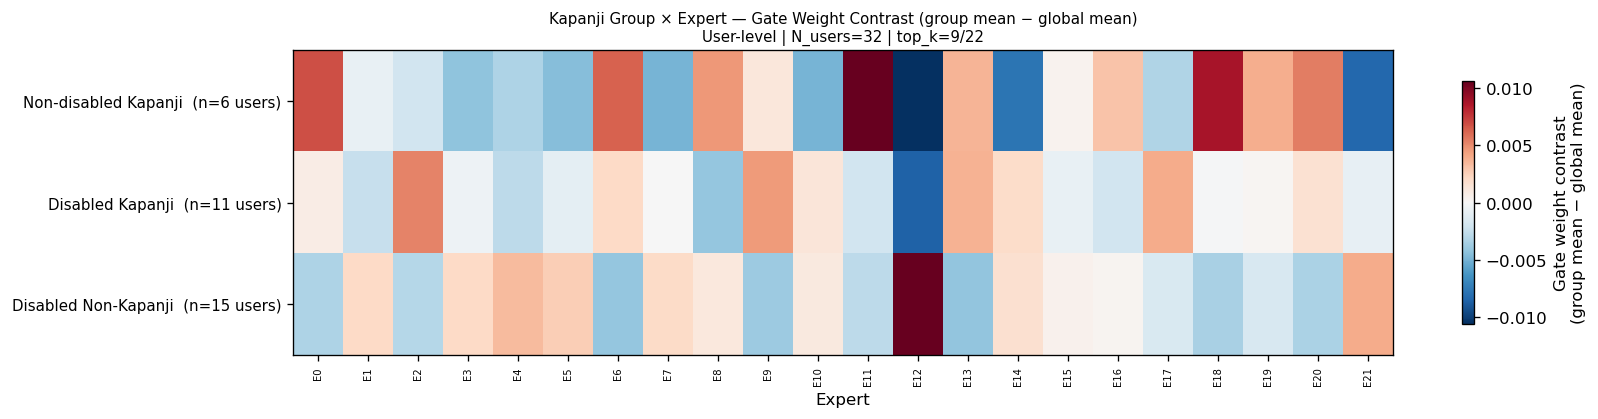

In [ ]:
all_kapanji_pids   = set().union(*KAPANJI_GROUPS.values())
unassigned         = set(unique_pids) - all_kapanji_pids
if unassigned:
    print(f"WARNING: {len(unassigned)} val PIDs have no Kapanji group: {sorted(unassigned)}")

global_mean_kap = user_gw.mean(axis=0)   # (E,)
group_names     = list(KAPANJI_GROUPS.keys())
n_groups        = len(group_names)
mat_kap         = np.zeros((n_groups, E))
group_sizes     = {}

for g_idx, group_name in enumerate(group_names):
    group_pid_set = KAPANJI_GROUPS[group_name]
    mask          = np.array([p in group_pid_set for p in unique_pids])
    n_in_group    = mask.sum()
    group_sizes[group_name] = n_in_group
    if n_in_group == 0:
        print(f"  WARNING: '{group_name}' has 0 users in val set. Row will be zero.")
        continue
    mat_kap[g_idx] = user_gw[mask].mean(axis=0) - global_mean_kap

print("Kapanji group user counts:")
for name, n in group_sizes.items():
    print(f"  {name}: {n} users")

vlim_kap = max(abs(mat_kap).max(), 0.005)

fig, ax = plt.subplots(figsize=(max(10, E * 0.55 + 2), max(3, n_groups * 0.7 + 1.5)))
im = ax.imshow(mat_kap, aspect='auto', vmin=-vlim_kap, vmax=vlim_kap, cmap='RdBu_r')
ax.set_xticks(range(E))
ax.set_xticklabels([f'E{i}' for i in range(E)], rotation=90, fontsize=6)
ax.set_yticks(range(n_groups))
ax.set_yticklabels([f"{n}  (n={group_sizes[n]} users)" for n in group_names], fontsize=9)
ax.set_xlabel('Expert')
#ax.set_title(
#    f"Kapanji Group × Expert — Gate Weight Contrast (group mean − global mean)\n"
#    f"User-level | N_users={N_users} | top_k={TOPK}/{E}",
#    fontsize=9,
#)
plt.colorbar(im, ax=ax, label='Gate weight contrast\n(group mean − global mean)', shrink=0.8)
fig.tight_layout()
plt.savefig(f'MOE_Kapanji_Heatmap.png', bbox_inches='tight', dpi=500)
plt.show()

---
# FIGURE 3 — Morphology Heatmap (PWD users only)

Loads morphology data (`gesture_features`) directly from the tensor dict.
For each user, averages their gesture-level feature vectors into a single user-level vector.
Users with `gesture_features=None` (PWoD users and P124) are skipped and reported.

Rows = users with disabilities who have morphology data.
Columns = morphology feature dimensions (time_sec + OHE dummies: hand_used, midair_or_table,
muscles_1, muscles_union, lifted_arms, dynamic_gesture).

In [12]:
# ── Load tensor dict ──────────────────────────────────────────────────────
with open(TENSOR_DICT_PATH, 'rb') as f:
    full_dict = pickle.load(f)

data_dict           = full_dict['data']
gesture_feature_cols = full_dict['gesture_feature_cols']   # list of column name strings
pwod_pids_from_dict  = full_dict['pwod_pids']              # set of PWoD PIDs (gesture_features=None)

print(f"Tensor dict loaded. Total PIDs in dict: {len(data_dict)}")
print(f"Gesture feature columns ({len(gesture_feature_cols)}): {gesture_feature_cols}")
print(f"PWoD PIDs (will be skipped): {sorted(pwod_pids_from_dict)}")

# ── Build user-level morphology matrix ────────────────────────────────────
# We only include users that are in the current routing analysis (unique_pids).
# For each included user, average gesture_features tensors across all gesture classes.
# Users with gesture_features=None are skipped (PWoD + P124).

morph_pids   = []   # PIDs included in the heatmap
morph_vecs   = []   # one averaged feature vector per included user
skipped_pids = []   # PIDs skipped because gesture_features is None

for pid in unique_pids:   # unique_pids from routing analysis
    if pid not in data_dict:
        # This would be a real data integrity issue, so raise rather than silently skip
        raise KeyError(f"PID {pid} is in routing analysis but not found in tensor dict!")

    pid_entries = data_dict[pid]   # dict: enc_gesture_id -> entry

    # Collect gesture_features from all gesture classes for this user
    feat_tensors = []
    for enc_gid, entry in pid_entries.items():
        gf = entry['gesture_features']
        if gf is not None:
            feat_tensors.append(gf)

    if len(feat_tensors) == 0:
        # All gestures returned None -> this user has no morphology data
        skipped_pids.append(pid)
        continue

    # Average across gesture classes to get one user-level morphology vector
    user_morph = torch.stack(feat_tensors).mean(dim=0).numpy()   # (D_gesture_features,)
    morph_pids.append(pid)
    morph_vecs.append(user_morph)

print(f"\nUsers included in morphology heatmap : {len(morph_pids)}")
print(f"Users skipped (gesture_features=None): {len(skipped_pids)}")
print(f"  Skipped PIDs: {sorted(skipped_pids)}")

assert len(morph_vecs) > 0, "No users with morphology data found — check tensor dict."

morph_matrix = np.stack(morph_vecs)   # (N_morph_users, D_gesture_features)
print(f"\nMorphology matrix shape: {morph_matrix.shape}  (users x features)")

Tensor dict loaded. Total PIDs in dict: 32
Gesture feature columns (34): ['time_sec', 'hand_used_both', 'hand_used_head', 'hand_used_left', 'hand_used_right', 'hand_used_shoulder', 'midair_or_table_midair', 'midair_or_table_neither', 'midair_or_table_on a 2d plane but not on table', 'midair_or_table_on table', 'muscles_1_fingers', 'muscles_1_shoulder', 'muscles_1_upper-body (bicep/tricep)', 'muscles_1_wrist/forearm', 'muscles_union_fingers', 'muscles_union_fingers|shoulder', 'muscles_union_fingers|shoulder|upper-body (bicep/tricep)', 'muscles_union_fingers|shoulder|wrist/forearm', 'muscles_union_fingers|upper-body (bicep/tricep)', 'muscles_union_fingers|upper-body (bicep/tricep)|wrist/forearm', 'muscles_union_fingers|wrist/forearm', 'muscles_union_shoulder', 'muscles_union_shoulder|upper-body (bicep/tricep)', 'muscles_union_shoulder|upper-body (bicep/tricep)|wrist/forearm', 'muscles_union_shoulder|wrist/forearm', 'muscles_union_upper-body (bicep/tricep)', 'muscles_union_upper-body (bic

Users with both routing data and morphology data: 25
Gate weight matrix   : (25, 22)   (users × experts)
Morphology matrix    : (25, 34)  (users × features)

Correlation matrix shape: (34, 22)  (D_features × E_experts)
Max |r|: 0.743  at feature='midair_or_table_on a 2d plane but not on table', expert=E8


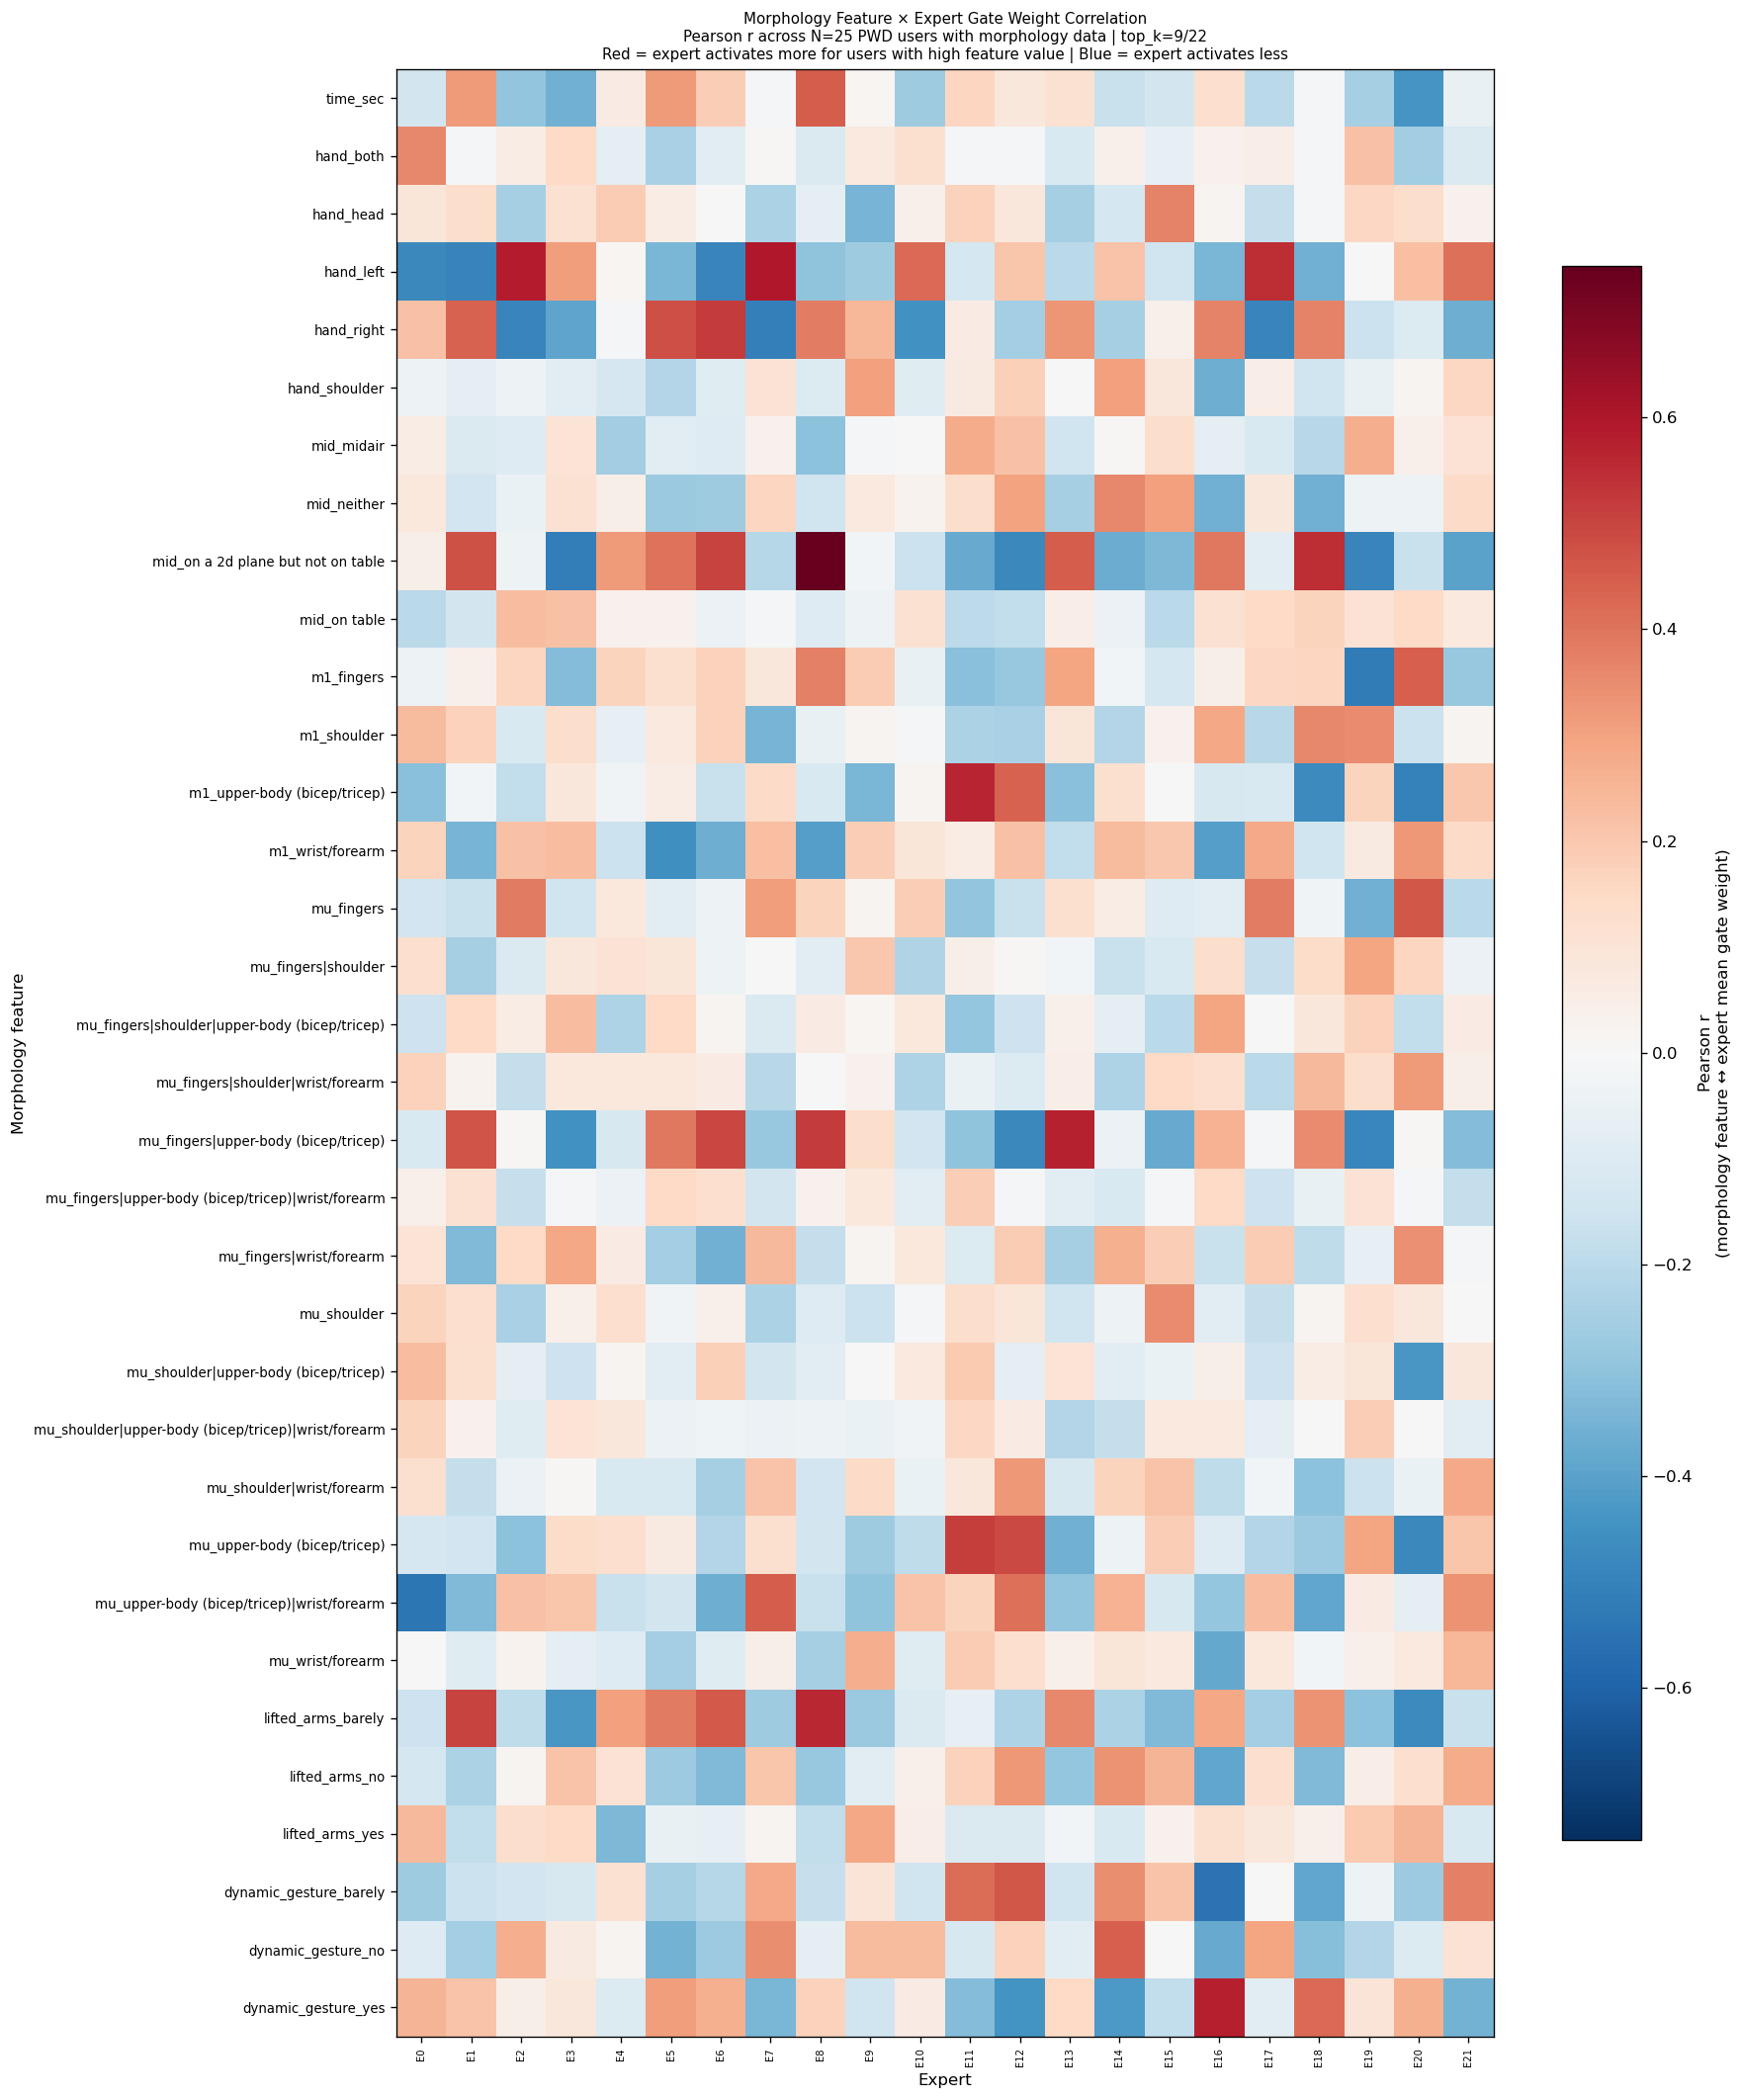


Top 10 |r| feature–expert pairs:
   1. midair_or_table_on a 2d plane but not on table ↔ E8    r=+0.743
   2. hand_used_left                           ↔ E7    r=+0.597
   3. hand_used_left                           ↔ E2    r=+0.584
   4. dynamic_gesture_yes                      ↔ E16   r=+0.578
   5. muscles_union_fingers|upper-body (bicep/tricep) ↔ E13   r=+0.570
   6. muscles_1_upper-body (bicep/tricep)      ↔ E11   r=+0.563
   7. lifted_arms_barely                       ↔ E8    r=+0.558
   8. hand_used_left                           ↔ E17   r=+0.549
   9. dynamic_gesture_barely                   ↔ E16   r=-0.547
  10. midair_or_table_on a 2d plane but not on table ↔ E18   r=+0.547


In [14]:
# ---
# FIGURE 3 — Morphology Feature × Expert Gate Weight Correlation
#
# For each PWD user that has morphology data, we correlate their per-expert
# mean gate weight (from the routing analysis) with each of their morphology
# feature values.  This produces a (D_features × E) Pearson-r matrix:
#   - Rows  = morphology features  (y-axis)
#   - Cols  = experts              (x-axis)
#   - Color = Pearson r between that feature and that expert's mean gate weight,
#             computed across all users who have morphology data.
#
# This is the scientifically meaningful version of Figure 3: it directly links
# what the gate learns to activate with the user's physical presentation,
# rather than just showing raw feature values.
#
# Prerequisites (all produced by earlier cells):
#   unique_pids   — list of all PIDs in routing analysis
#   user_gw       — np.ndarray (N_users, E), mean gate weight per user
#   morph_pids    — list of PIDs that have morphology data (from Figure 3 setup)
#   morph_matrix  — np.ndarray (N_morph_users, D), user-level morphology vectors
#   gesture_feature_cols — list of D feature name strings
#   pid_to_kapanji, group_abbrevs, KAPANJI_GROUPS — from Figure 2 setup
# ---

import numpy as np

# ── Step 1: Align morphology users with routing user_gw ──────────────────────
# user_gw rows are indexed by unique_pids (sorted).  morph_pids may be a subset
# and in a different order.  We need the gate weight row for each morph user.

unique_pids_list = sorted(set(record.pids))   # same order as user_gw rows
pid_to_gw_idx    = {pid: i for i, pid in enumerate(unique_pids_list)}

# Only keep morph users that are also in the routing analysis
morph_pids_aligned = []
morph_gw_aligned   = []   # gate weight vectors for these users
morph_feat_aligned = []   # morphology feature vectors for these users

for i, pid in enumerate(morph_pids):
    assert pid in pid_to_gw_idx, (
        f"PID {pid} has morphology data but is not in routing analysis — "
        f"recheck that val_dl covers the same users as the tensor dict."
    )
    morph_pids_aligned.append(pid)
    morph_gw_aligned.append(user_gw[pid_to_gw_idx[pid]])   # (E,)
    morph_feat_aligned.append(morph_matrix[i])              # (D,)

morph_gw_mat   = np.stack(morph_gw_aligned)    # (N_morph, E)
morph_feat_mat = np.stack(morph_feat_aligned)  # (N_morph, D)
N_morph = len(morph_pids_aligned)

print(f"Users with both routing data and morphology data: {N_morph}")
print(f"Gate weight matrix   : {morph_gw_mat.shape}   (users × experts)")
print(f"Morphology matrix    : {morph_feat_mat.shape}  (users × features)")

# ── Step 2: Compute Pearson r — (D × E) correlation matrix ───────────────────
D = morph_feat_mat.shape[1]
corr_matrix = np.zeros((D, E))  # rows=features, cols=experts

for f_idx in range(D):
    f_col = morph_feat_mat[:, f_idx]
    if f_col.std() < 1e-8:
        # Constant feature across all users — correlation undefined, leave as 0
        print(f"  WARNING: feature '{gesture_feature_cols[f_idx]}' is constant across morph users — skipping.")
        continue
    for e_idx in range(E):
        e_col = morph_gw_mat[:, e_idx]
        if e_col.std() < 1e-8:
            corr_matrix[f_idx, e_idx] = 0.0
        else:
            corr_matrix[f_idx, e_idx] = float(np.corrcoef(f_col, e_col)[0, 1])

print(f"\nCorrelation matrix shape: {corr_matrix.shape}  (D_features × E_experts)")
print(f"Max |r|: {np.abs(corr_matrix).max():.3f}  at feature='{gesture_feature_cols[np.unravel_index(np.abs(corr_matrix).argmax(), corr_matrix.shape)[0]]}', expert=E{np.unravel_index(np.abs(corr_matrix).argmax(), corr_matrix.shape)[1]}")

# ── Step 3: Shorten feature names for readability ────────────────────────────
def shorten_col(col: str) -> str:
    replacements = [
        ('muscles_union_', 'mu_'),
        ('muscles_1_',     'm1_'),
        ('hand_used_',     'hand_'),
        ('midair_or_table_', 'mid_'),
    ]
    for old, new in replacements:
        col = col.replace(old, new)
    return col

feat_labels = [shorten_col(c) for c in gesture_feature_cols]
expert_labels = [f'E{i}' for i in range(E)]

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
vlim = max(abs(corr_matrix).max(), 0.05)   # symmetric colorbar; floor at 0.05 so
                                            # a near-zero matrix doesn't look noisy

fig_h = max(5, D * 0.45 + 2.5)
fig_w = max(10, E * 0.55 + 3)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(
    corr_matrix,
    aspect='auto',
    vmin=-vlim, vmax=vlim,
    cmap='RdBu_r',
    interpolation='nearest',
)

ax.set_xticks(range(E))
ax.set_xticklabels(expert_labels, rotation=90, fontsize=6)
ax.set_yticks(range(D))
ax.set_yticklabels(feat_labels, fontsize=8)
ax.set_xlabel('Expert', fontsize=10)
ax.set_ylabel('Morphology feature', fontsize=10)
ax.set_title(
    f"Morphology Feature × Expert Gate Weight Correlation\n"
    f"Pearson r across N={N_morph} PWD users with morphology data | top_k={TOPK}/{E}\n"
    f"Red = expert activates more for users with high feature value | "
    f"Blue = expert activates less",
    fontsize=9,
)
plt.colorbar(
    im, ax=ax,
    label="Pearson r\n(morphology feature ↔ expert mean gate weight)",
    shrink=0.8,
)
fig.tight_layout()
plt.show()

# ── Step 5: Print top correlations for inspection ─────────────────────────────
print("\nTop 10 |r| feature–expert pairs:")
flat_idx = np.argsort(np.abs(corr_matrix).ravel())[::-1]
for rank, idx in enumerate(flat_idx[:10]):
    f_i, e_i = np.unravel_index(idx, corr_matrix.shape)
    print(f"  {rank+1:2d}. {gesture_feature_cols[f_i]:<40s} ↔ E{e_i:<3d}  r={corr_matrix[f_i, e_i]:+.3f}")

Feature group assignments:
  [Hand Used] (5 features)
      'hand_used_both'                                   → 'Both'
      'hand_used_head'                                   → 'Head'
      'hand_used_left'                                   → 'Left'
      'hand_used_right'                                  → 'Right'
      'hand_used_shoulder'                               → 'Shoulder'
  [Surface] (4 features)
      'midair_or_table_midair'                           → 'Midair'
      'midair_or_table_neither'                          → 'Neither'
      'midair_or_table_on a 2d plane but not on table'   → 'On A 2D Plane But Not On Table'
      'midair_or_table_on table'                         → 'On Table'
  [Primary Muscle] (4 features)
      'muscles_1_fingers'                                → 'Fingers'
      'muscles_1_shoulder'                               → 'Shoulder'
      'muscles_1_upper-body (bicep/tricep)'              → 'Upper-Body (Bicep/Tricep)'
      'muscles_1_wrist/forear

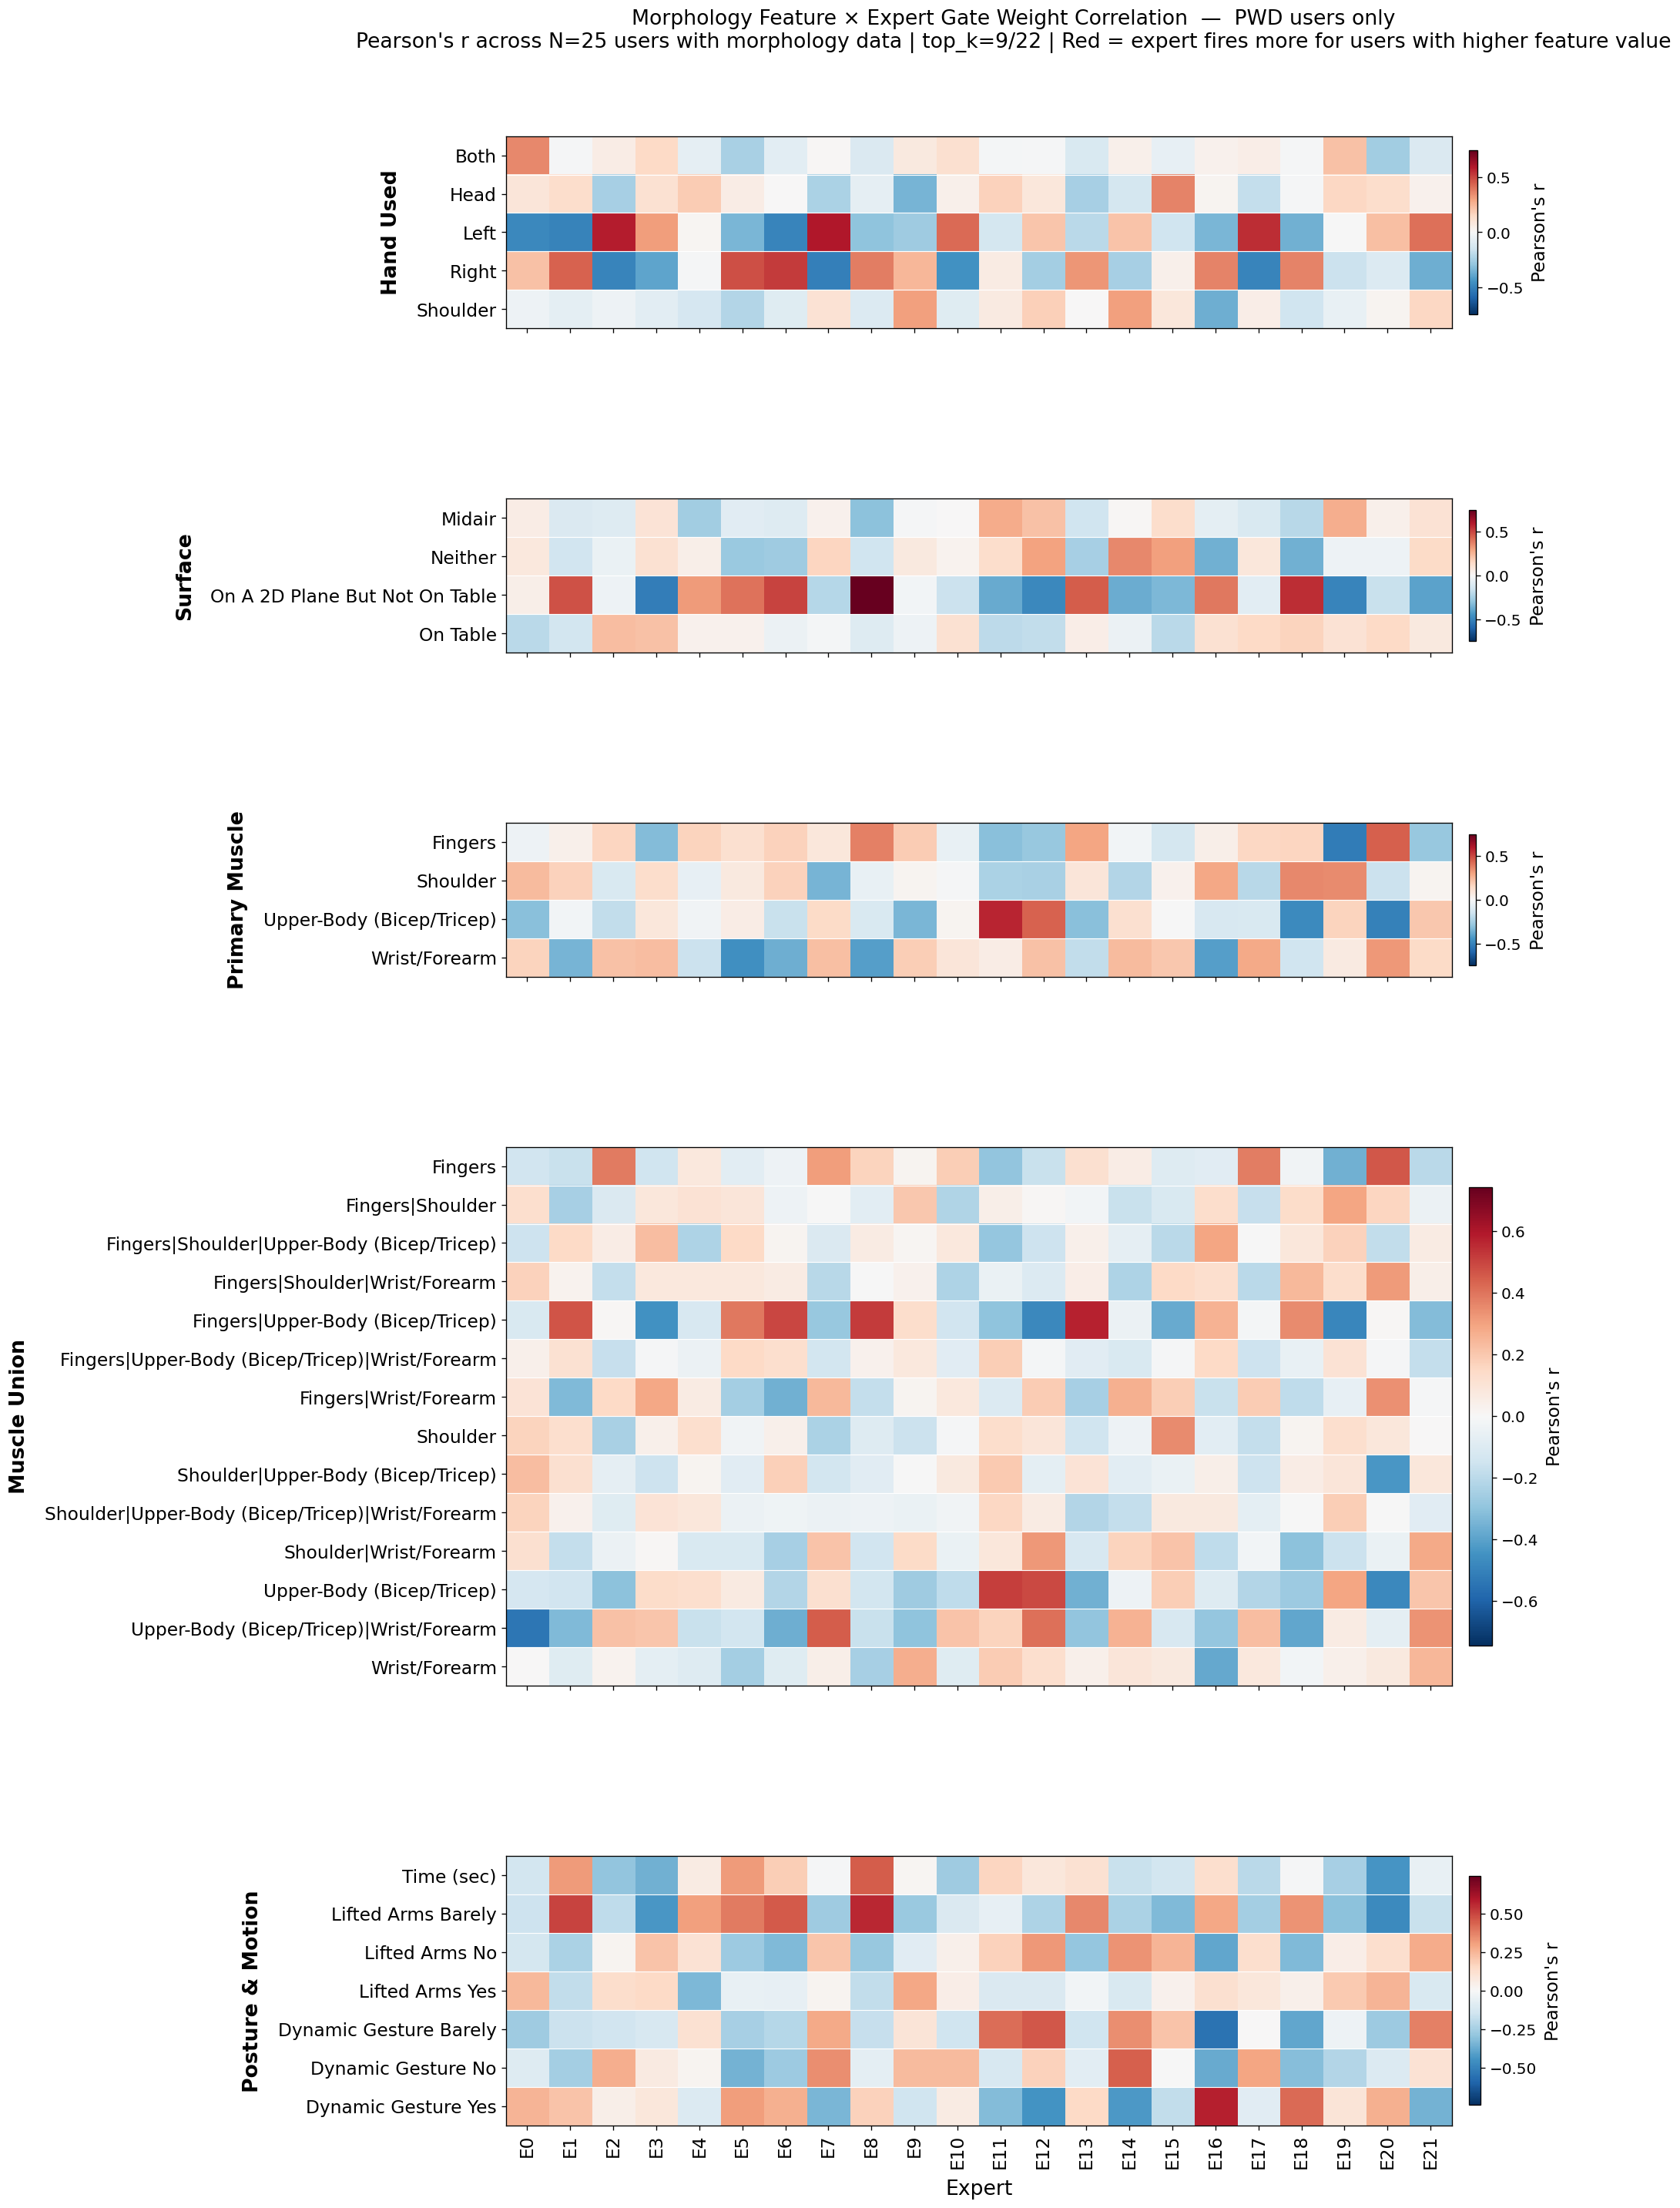


Top 3 |r| pairs per feature group:

  [Hand Used]
    1. hand_used_left                                ↔ E7    r=+0.597
    2. hand_used_left                                ↔ E2    r=+0.584
    3. hand_used_left                                ↔ E17   r=+0.549

  [Surface]
    1. midair_or_table_on a 2d plane but not on table ↔ E8    r=+0.743
    2. midair_or_table_on a 2d plane but not on table ↔ E18   r=+0.547
    3. midair_or_table_on a 2d plane but not on table ↔ E3    r=-0.512

  [Primary Muscle]
    1. muscles_1_upper-body (bicep/tricep)           ↔ E11   r=+0.563
    2. muscles_1_fingers                             ↔ E19   r=-0.522
    3. muscles_1_upper-body (bicep/tricep)           ↔ E20   r=-0.505

  [Muscle Union]
    1. muscles_union_fingers|upper-body (bicep/tricep) ↔ E13   r=+0.570
    2. muscles_union_upper-body (bicep/tricep)|wrist/forearm ↔ E0    r=-0.537
    3. muscles_union_fingers|upper-body (bicep/tricep) ↔ E8    r=+0.517

  [Posture & Motion]
    1. dynamic_gestur

In [ ]:
# ---
# FIGURE 3 (segmented subplots, v2) — Morphology Feature × Expert Correlation
#
# Prerequisites: run NB_cell_figure3_replacement.py first so that
#   corr_matrix, group_indices (if already defined), gesture_feature_cols,
#   morph_gw_mat, morph_feat_mat, N_morph, E, TOPK  are all in scope.
# ---

import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Feature group definitions ─────────────────────────────────────────────────
# (subplot_title, prefix_to_strip, regex_to_match_col_name)
FEATURE_GROUPS = [
    ('Hand Used',       'hand_used_',         r'^hand_used_'),
    ('Surface',         'midair_or_table_',   r'^midair_or_table_'),
    ('Primary Muscle',  'muscles_1_',         r'^muscles_1_'),
    ('Muscle Union',    'muscles_union_',     r'^muscles_union_'),
    ('Posture & Motion', None,                r'^(lifted_arms|dynamic_gesture|time_sec)'),
]

# ── Label overrides ───────────────────────────────────────────────────────────
# Maps raw suffix (after prefix strip, lowercased) → display label.
# Add any other awkward OHE category strings here.
LABEL_OVERRIDES = {
    # Surface group — the OHE category names can be long / oddly worded
    'on a 2d plane but not on the table': 'Midair 2D Plane',
    'on a 2d plane but not on the table ': 'Midair 2D Plane',  # trailing space variant
    'midair':                              'Midair',
    'on the table':                        'On Table',
    'table':                               'On Table',
    # Posture & Motion — strip underscores already handled, but keep tidy
    'lifted arms':                         'Lifted Arms',
    'dynamic gesture':                     'Dynamic Gesture',
    'time sec':                            'Time (sec)',
}

def make_ytick(col: str, prefix: str | None) -> str:
    """Strip prefix, apply any override, then Title-case."""
    raw = col[len(prefix):] if (prefix and col.startswith(prefix)) else col
    raw_clean = raw.replace('_', ' ').strip()
    # Check override (case-insensitive key lookup)
    override = LABEL_OVERRIDES.get(raw_clean.lower())
    if override:
        return override
    # Default: Title Case
    return raw_clean.title()

# ── Assign columns to groups ──────────────────────────────────────────────────
group_indices = []
for col in gesture_feature_cols:
    matched = -1
    for i, (_, _, pattern) in enumerate(FEATURE_GROUPS):
        if re.match(pattern, col):
            matched = i
            break
    assert matched != -1, (
        f"Column '{col}' did not match any FEATURE_GROUPS entry — "
        f"add a matching regex to FEATURE_GROUPS."
    )
    group_indices.append(matched)

group_indices = np.array(group_indices)
n_groups = len(FEATURE_GROUPS)

print("Feature group assignments:")
for g_idx, (title, prefix, _) in enumerate(FEATURE_GROUPS):
    cols_in = [gesture_feature_cols[i] for i, g in enumerate(group_indices) if g == g_idx]
    ticks   = [make_ytick(c, prefix) for c in cols_in]
    print(f"  [{title}] ({len(cols_in)} features)")
    for c, t in zip(cols_in, ticks):
        print(f"      {c!r:50s} → {t!r}")

# ── Layout ────────────────────────────────────────────────────────────────────
row_counts = [int((group_indices == g).sum()) for g in range(n_groups)]
assert all(r > 0 for r in row_counts), f"Empty group — row_counts={row_counts}"

FONT_BASE  = 14
EXPERT_W   = 0.65   # inches per expert
FEATURE_H  = 0.58   # inches per feature row
FIG_W      = max(14, E * EXPERT_W + 4)
FIG_H      = sum(max(2.0, r * FEATURE_H) for r in row_counts) + n_groups * 0.7 + 1.8

expert_labels = [f'E{i}' for i in range(E)]
vlim = max(np.abs(corr_matrix).max(), 0.05)

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = gridspec.GridSpec(
    n_groups, 1,
    hspace        = 0.65,
    height_ratios = row_counts,
    left=0.20, right=0.87, top=0.93, bottom=0.07,
)
axes = [fig.add_subplot(gs[g]) for g in range(n_groups)]

for g_idx, (title, prefix, _) in enumerate(FEATURE_GROUPS):
    ax        = axes[g_idx]
    feat_mask = group_indices == g_idx
    sub_corr  = corr_matrix[feat_mask, :]     # (D_group, E)
    sub_cols  = [gesture_feature_cols[i]
                 for i, g in enumerate(group_indices) if g == g_idx]
    ytick_labels = [make_ytick(c, prefix) for c in sub_cols]

    im = ax.imshow(
        sub_corr,
        aspect='auto',
        vmin=-vlim, vmax=vlim,
        cmap='RdBu_r',
        interpolation='nearest',
    )

    # X axis — labels only on the bottom subplot
    ax.set_xticks(range(E))
    if g_idx == n_groups - 1:
        ax.set_xticklabels(expert_labels, rotation=90, fontsize=FONT_BASE)
        ax.set_xlabel('Expert', fontsize=FONT_BASE + 2, labelpad=8)
    else:
        ax.set_xticklabels([])

    # Y axis — clean capitalized value labels
    ax.set_yticks(range(sub_corr.shape[0]))
    ax.set_yticklabels(ytick_labels, fontsize=FONT_BASE)

    # Bold group title as y-axis label
    ax.set_ylabel(title, fontsize=FONT_BASE + 2, fontweight='bold', labelpad=12)

    # Minor gridlines between rows
    ax.set_yticks(np.arange(-0.5, sub_corr.shape[0], 1), minor=True)
    ax.grid(which='minor', axis='y', color='white', linewidth=0.7)
    ax.tick_params(which='minor', left=False)

    # Colorbar on every subplot, all labeled "Pearson's r"
    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.015)
    cbar.set_label("Pearson's r", fontsize=FONT_BASE, labelpad=6)
    cbar.ax.tick_params(labelsize=FONT_BASE - 2)

# ── Overall title ─────────────────────────────────────────────────────────────
#fig.suptitle(
#    f"Morphology Feature × Expert Gate Weight Correlation  —  PWD users only\n"
#    f"Pearson's r across N={N_morph} users with morphology data | "
#    f"top_k={TOPK}/{E} | Red = expert fires more for users with higher feature value",
#    fontsize=FONT_BASE + 2,
#    y=0.985,
#)

plt.savefig(f'MOE_Morphology_Heatmap.png', bbox_inches='tight', dpi=500)
plt.show()

# ── Top correlations per group ────────────────────────────────────────────────
print("\nTop 3 |r| pairs per feature group:")
for g_idx, (title, prefix, _) in enumerate(FEATURE_GROUPS):
    feat_mask = group_indices == g_idx
    sub_corr  = corr_matrix[feat_mask, :]
    sub_cols  = [gesture_feature_cols[i]
                 for i, g in enumerate(group_indices) if g == g_idx]
    flat_order = np.argsort(np.abs(sub_corr).ravel())[::-1]
    print(f"\n  [{title}]")
    for rank, idx in enumerate(flat_order[:3]):
        f_i, e_i = np.unravel_index(idx, sub_corr.shape)
        print(f"    {rank+1}. {sub_cols[f_i]:<45s} ↔ E{e_i:<3d}  r={sub_corr[f_i, e_i]:+.3f}")